In [2]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [3]:
import sys

sys.path.append('../scripts')

In [4]:
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import cpa

from tqdm import tqdm

from utils import set_seed

Global seed set to 0


In [5]:
set_seed(0)

In [6]:
batch_size = 4096

## Load data

In [7]:
adata = sc.read(
    "/data2/a330d/datasets/cosmx/crc_wt_cosmx/crc_202.h5ad",
    backup_url="https://zenodo.org/records/15574384/files/242.h5ad?download=1"
)
# adata.obsm = {} # NOTE: only some strange PCA embeddings are stored in obsm, which we don't need
adata.obs_names_make_unique()

label_to_coarse = {
    "epi1": "Epithelial",
    "epi2": "Epithelial",
    "epi3": "Epithelial",
    "epi4": "Epithelial",
    
    "fib1": "Fibroblast",
    "fib2": "Fibroblast",
    
    "EC": "Endothelial",
    "SMC": "Smooth_muscle",
    
    "BC": "B_cell",
    "PC_IgA": "Plasma_cell",
    "PC_IgG": "Plasma_cell",
    "PC_IgM": "Plasma_cell",
    
    "TC": "T_cell",
    
    "mye1": "Myeloid",
    "mye2": "Myeloid",
    
    "mast": "Mast_cell",
}

adata.obs["coarse_type"] = adata.obs['ist'].map(label_to_coarse)
labels_key = 'coarse_type'
domains_key = 'typ'
batch_key = 'sid'
adata = adata[~adata.obs[domains_key].isna()] # NOTE: Interesting to annotate?
adata = adata[~adata.obs[labels_key].isna()]

sc.pp.filter_cells(adata, min_counts=3)
sc.pp.filter_genes(adata, min_counts=3)

In [8]:
adata.obs[labels_key] = adata.obs[labels_key].astype('category')
adata.obsm['spatial'] = adata.obs[['CenterX_global_px', 'CenterY_global_px']].values
adata.layers['counts'] = adata.X.copy()
sc.pp.highly_variable_genes(adata, layer='counts', flavor='seurat_v3', n_top_genes=2000, subset=True)

## Data splits

In [9]:
split = "ood"

# Get holdout indices
if split == "random":
    fraction = 0.1
    n_cells = adata.n_obs
    n_holdout = int(n_cells * fraction)

    # Randomly choose cells
    test_idx = np.random.choice(n_cells, n_holdout, replace=False)

elif split == "ood":
    # OOD: Non-ref, non-epithelial
    #is_tumor_region  = adata.obs["typ"].str.contains("CRC|TVA", regex=True)
    is_tumor_region  = adata.obs["typ"].str.contains("CRC", regex=True)
    is_non_epi = adata.obs["coarse_type"] != "Epithelial"

    # Combine for test set
    test_mask = (is_tumor_region) & (is_non_epi)
    test_idx = np.where(test_mask)[0]
else:
    raise ValueError(f"Unknown split: {split}")

# Get train/val indices
all_idx = np.arange(adata.n_obs)
trainval_idx = np.setdiff1d(all_idx, test_idx)

In [10]:
from sklearn.model_selection import train_test_split

validation_size = 0.1
train_idx, val_idx = train_test_split(
    trainval_idx,
    test_size=validation_size,
    random_state=0,
    shuffle=True,
)

In [11]:
# Set 'is_holdout' to False by default, then True for selected cells
adata.obs['is_holdout'] = False
adata.obs.iloc[test_idx, adata.obs.columns.get_loc('is_holdout')] = True

In [12]:
adata.obs['data_split'] = 'train'
adata.obs.iloc[val_idx, adata.obs.columns.get_loc('data_split')] = 'valid'
adata.obs.iloc[test_idx, adata.obs.columns.get_loc('data_split')] = 'ood'

## Model selection

In [13]:
base_path = "/data2/a330d/data/cellina-reproducibility"

In [14]:
model_class = 'cpa'

In [15]:
adata.X = adata.layers['counts'].copy()

In [16]:
adata.obs['dose'] = '1.0' # NOTE: dummy dose for compatibility with CPA model

# Set perturbation column to 'perturbed' for cells in CRC region, REF and TVA are controls
adata.obs['perturbation'] = 'ctrl'
mask = np.zeros(adata.n_obs, dtype=bool)
mask[is_tumor_region] = True
adata.obs.loc[mask, "perturbation"] = 'perturbed'

In [17]:
cpa.CPA.setup_anndata(adata,
                      perturbation_key='perturbation',
                      control_group='ctrl',
                      dosage_key='dose',
                      categorical_covariate_keys=[labels_key],
                      is_count_data=True,
                      max_comb_len=1,
                     )

100%|██████████| 420694/420694 [00:00<00:00, 1632129.94it/s]
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


INFO     Generating sequential column names                                                                        
INFO     Generating sequential column names                                                                        


In [18]:
model_params = {
    "n_latent": 64,
    "recon_loss": "nb",
    "doser_type": "linear",
    "n_hidden_encoder": 128,
    "n_layers_encoder": 2,
    "n_hidden_decoder": 512,
    "n_layers_decoder": 2,
    "use_batch_norm_encoder": True,
    "use_layer_norm_encoder": False,
    "use_batch_norm_decoder": False,
    "use_layer_norm_decoder": True,
    "dropout_rate_encoder": 0.0,
    "dropout_rate_decoder": 0.1,
    "variational": False,
    "seed": 6977,
}

trainer_params = {
    "n_epochs_kl_warmup": None,
    "n_epochs_pretrain_ae": 30,
    "n_epochs_adv_warmup": 50,
    "n_epochs_mixup_warmup": 0,
    "mixup_alpha": 0.0,
    "adv_steps": None,
    "n_hidden_adv": 64,
    "n_layers_adv": 3,
    "use_batch_norm_adv": True,
    "use_layer_norm_adv": False,
    "dropout_rate_adv": 0.3,
    "reg_adv": 20.0,
    "pen_adv": 5.0,
    "lr": 0.0003,
    "wd": 4e-07,
    "adv_lr": 0.0003,
    "adv_wd": 4e-07,
    "adv_loss": "cce",
    "doser_lr": 0.0003,
    "doser_wd": 4e-07,
    "do_clip_grad": True,
    "gradient_clip_value": 1.0,
    "step_size_lr": 10,
}

In [19]:
model = cpa.CPA(adata=adata,
                split_key='data_split',
                train_split='train',
                valid_split='valid',
                test_split='ood',
                **model_params,
               )

Global seed set to 6977


In [20]:
model.train(max_epochs=100,
            use_gpu=True,
            batch_size=batch_size,
            plan_kwargs=trainer_params,
            early_stopping_patience=5,
            check_val_every_n_epoch=5,
            save_path=f'{base_path}/cpa/lightning_logs/Kang/',
           )

100%|██████████| 2/2 [00:00<00:00,  6.82it/s]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Epoch 5/100:   4%|▍         | 4/100 [02:06<50:06, 31.32s/it, v_num=1, recon=433, r2_mean=0.754, adv_loss=0.589, acc_pert=0.939, acc_coarse_type=0.878]


Epoch 00004: cpa_metric reached. Module best state updated.


Epoch 10/100:   9%|▉         | 9/100 [05:03<51:43, 34.11s/it, v_num=1, recon=422, r2_mean=0.775, adv_loss=0.426, acc_pert=0.961, acc_coarse_type=0.891, val_recon=431, disnt_basal=1.14, disnt_after=1.98, val_r2_mean=0.758, val_KL=nan]


Epoch 00009: cpa_metric reached. Module best state updated.


...


disnt_basal = 0.9405660888421288
disnt_after = 1.9845833333333336
val_r2_mean = 0.7520160893599193
val_r2_var = 0.6706454992294313
Epoch 45/100:  44%|████▍     | 44/100 [20:44<20:32, 22.01s/it, v_num=1, recon=405, r2_mean=0.783, adv_loss=1.6, acc_pert=0.501, acc_coarse_type=0.769, val_recon=410, disnt_basal=0.941, disnt_after=1.98, val_r2_mean=0.752, val_KL=nan] 


Epoch 00044: cpa_metric reached. Module best state updated.


Epoch 50/100:  49%|████▉     | 49/100 [22:38<19:02, 22.40s/it, v_num=1, recon=404, r2_mean=0.782, adv_loss=1.57, acc_pert=0.5, acc_coarse_type=0.773, val_recon=409, disnt_basal=0.85, disnt_after=1.98, val_r2_mean=0.771, val_KL=nan]  


Epoch 00049: cpa_metric reached. Module best state updated.



disnt_basal = 0.83903251558146
disnt_after = 1.9845833333333336
val_r2_mean = 0.7558804763687982
val_r2_var = 0.6501975655555725
Epoch 60/100:  59%|█████▉    | 59/100 [26:39<16:22, 23.96s/it, v_num=1, recon=402, r2_mean=0.783, adv_loss=1.6, acc_pert=0.5, acc_coarse_type=0.773, val_recon=408, disnt_basal=0.895, disnt_after=1.99, val_r2_mean=0.755, val_KL=nan]   
disnt_basal = 0.9075244457278242
disnt_after = 1.9854166666666664
val_r2_mean = 0.7596655461523267
val_r2_var = 0.6656714141368866
Epoch 70/100:  69%|██████▉   | 69/100 [30:58<11:57, 23.14s/it, v_num=1, recon=401, r2_mean=0.786, adv_loss=1.57, acc_pert=0.5, acc_coarse_type=0.773, val_recon=406, disnt_basal=0.847, disnt_after=1.98, val_r2_mean=0.772, val_KL=nan]  
disnt_basal = 0.9419686003140016
disnt_after = 1.9870833333333333
val_r2_mean = 0.763659962018331
val_r2_var = 0.6672714319494035
Epoch 75/100:  75%|███████▌  | 75/100 [33:20<11:06, 26.67s/it, v_num=1, recon=400, r2_mean=0.79, adv_loss=1.57, acc_pert=0.5, acc_coarse_ty

## Analysis

In [20]:
model = cpa.CPA.load(dir_path=f'{base_path}/cpa/lightning_logs/Kang/',
                     adata=adata,
                     use_gpu=True)

INFO     File /data2/a330d/data/cellina-reproducibility/cpa/lightning_logs/Kang/model.pt already downloaded        


100%|██████████| 420694/420694 [00:00<00:00, 1659008.88it/s]
Global seed set to 6977


In [21]:
from counterfactual_analysis import get_counterfactual_preds

In [22]:
results_adatas = {k: {} for k in ['cpa']}

In [23]:
results_adatas[model_class] = get_counterfactual_preds(model, adata, labels_key, model_class)

  0%|          | 0/7 [00:00<?, ?it/s]

INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


100%|██████████| 184/184 [00:01<00:00, 181.36it/s]

INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        



100%|██████████| 184/184 [00:00<00:00, 345.60it/s]

...

100%|██████████| 459/459 [00:02<00:00, 209.57it/s]

INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        



100%|██████████| 459/459 [00:01<00:00, 254.36it/s]


INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


100%|██████████| 7/7 [01:09<00:00,  9.98s/it]


In [24]:
results_adatas

{'cpa': {'Endothelial': AnnData object with n_obs × n_vars = 13370 × 2000
      obs: 'fov', 'Area', 'AspectRatio', 'CenterX_local_px', 'CenterY_local_px', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68_CK8_18', 'Max.CD68_CK8_18', 'Mean.CD298_B2M', 'Max.CD298_B2M', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'cell_id', 'Dash', 'ISH.concentration', 'Panel', 'Run_Tissue_name', 'Run_name', 'assay_type', 'dualfiles', 'tissue', 'version', 'slide_ID', 'CenterX_global_px', 'CenterY_global_px', 'cell_ID', 'unassignedTranscripts', 'median_RNA', 'RNA_quantile_0.75', 'RNA_quantile_0.8', 'RNA_quantile_0.85', 'RNA_quantile_0.9', 'RNA_quantile_0.95', 'RNA_quantile_0.99', 'nCount_RNA', 'nFeature_RNA', 'median_negprobes', 'negprobes_quantile_0.75', 'negprobes_quantile_0.8', 'negprobes_quantile_0.85', 'negprobes_quantile_0.9', 'negprobes_quantile_0.95', 'negprobes_quantile_0.99', 'nCount_negprobes', 'nFeature_negprobes', 'median_falsecode', 'falsecode_quantile_0.75', 'falsecode_quantile_

  0%|          | 0/7 [00:00<?, ?it/s]

100%|██████████| 7/7 [00:02<00:00,  2.76it/s]


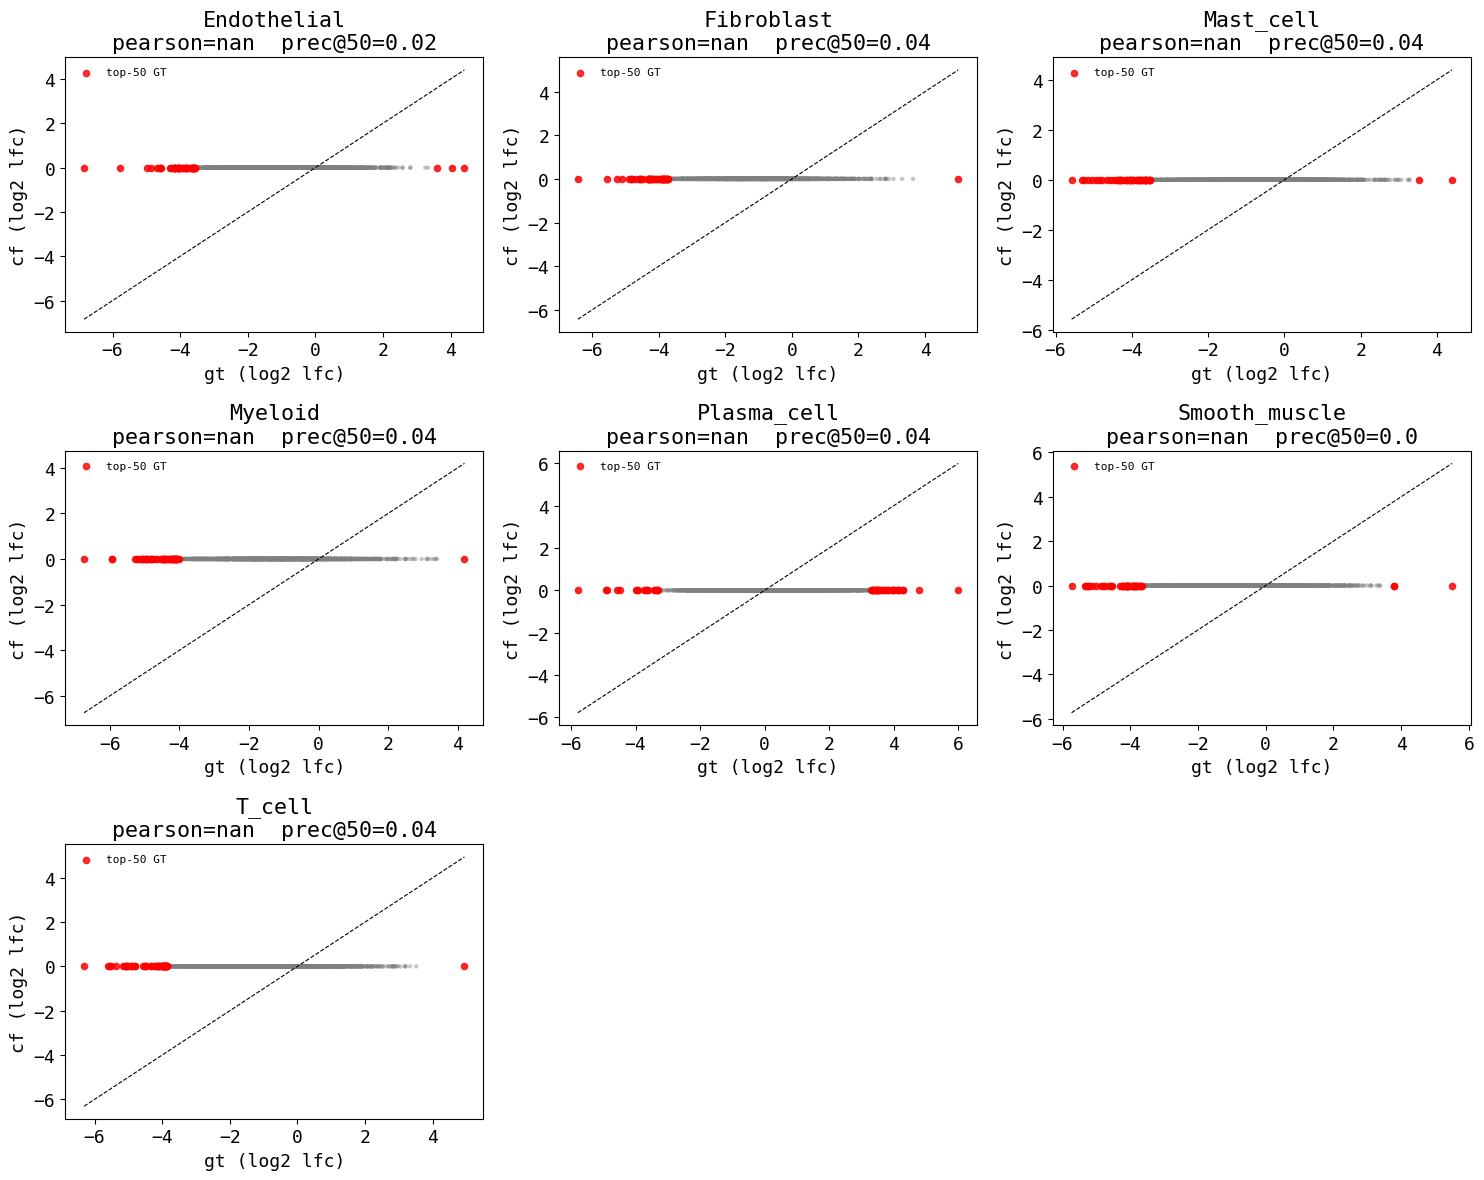

In [26]:
# Differential Expression
from counterfactual_analysis import get_de_correlations
k = 50
# cpa
results_cpa, vectors = get_de_correlations(results_adatas['cpa'], k=k, plot=True, use_recon=True)
metrics_cpa = pd.DataFrame(results_cpa).set_index('celltype').sort_values(by=f'prec@{k}', ascending=False)

In [27]:
results = []
vectors = {}
use_recon = True

for ct, adata in tqdm(results_adatas['cpa'].items()):
    groups = adata.obs["group"].values
    var_names = np.asarray(adata.var_names)

    # get counts as dense array
    counts = adata.layers["counts"]  # shape: (n_cells, n_genes)

    # get ground truth control, target either from raw counts or reconstructed counts
    if use_recon:
        X_all = adata.obsm.get("recon_x")
    else:
        # normalize counts so each row sums to 1
        X_all = counts / (counts.sum(axis=1, keepdims=True) + 1e-8)
    # model-normalized counterfactuals (may be None)
    recon_all = adata.obsm.get("recon_x")

    # masks
    mask_control = groups == "control"
    mask_target = groups == "target"
    mask_cf = groups == "counterfactual"

    if mask_control.sum() == 0:
        # can't compute without real control baseline
        continue
    if mask_target.sum() == 0 and mask_cf.sum() == 0:
        # nothing to compare
        continue

    # compute group means (ensure arrays)
    mean_control = (
        X_all[mask_control].mean(axis=0)
        if mask_control.sum() > 0
        else np.zeros(X_all.shape[1])
    )
    mean_target = (
        X_all[mask_target].mean(axis=0)
        if mask_target.sum() > 0
        else np.zeros(X_all.shape[1])
    )
    mean_cf = recon_all[mask_cf].mean(axis=0)
    print(mean_control)
    print(mean_target)
    print(mean_cf)

    # compute gt and cf: observed perturbed (target) minus real control, and counterfactual minus real control
    from counterfactual_analysis import safe_log2_fold_change
    diff_method = safe_log2_fold_change
    eps = 1e-6

    try:
        gt_vec = diff_method(mean_target, mean_control, eps=eps)
        cf_vec = diff_method(mean_cf, mean_control, eps=eps)
    except Exception:
        # numeric issues: skip
        continue

    vectors[ct] = {"gt": gt_vec, "cf": cf_vec, "genes": var_names}

    # compute Pearson and Spearman on finite entries
    valid = np.isfinite(gt_vec) & np.isfinite(cf_vec)
    if (
        valid.sum() < 2
        or (np.nanstd(gt_vec[valid]) == 0)
        or (np.nanstd(cf_vec[valid]) == 0)
    ):
        pear = np.nan
        spearman = np.nan
    else:
        from scipy.stats import pearsonr, spearmanr
        pear, _ = pearsonr(gt_vec[valid], cf_vec[valid])
        spearman, _ = spearmanr(gt_vec[valid], cf_vec[valid])

 29%|██▊       | 2/7 [00:00<00:00, 14.49it/s]

[0.00825969 0.00012676 0.00018232 ... 0.00013848 0.00017587 0.00025561]
[2.7123939e-03 6.4890948e-05 8.1085524e-04 ... 3.2755161e-05 2.4079975e-04
 1.2982063e-04]
[0.00825969 0.00012676 0.00018232 ... 0.00013848 0.00017587 0.00025561]
[0.007098   0.00014989 0.00033745 ... 0.00015662 0.00023533 0.00025977]
[1.1661173e-03 3.8786766e-05 1.0096561e-03 ... 4.8874266e-05 4.5648406e-04
 1.3468867e-04]
[0.007098   0.00014989 0.00033745 ... 0.00015662 0.00023533 0.00025977]
[0.00173243 0.0001532  0.00045397 ... 0.00026075 0.00043022 0.00025774]
[1.0470432e-03 7.4564960e-05 1.0925923e-03 ... 4.9266800e-05 5.1485782e-04
 2.9635461e-04]
[0.00173243 0.0001532  0.00045397 ... 0.00026075 0.00043022 0.00025774]


 57%|█████▋    | 4/7 [00:00<00:00, 15.67it/s]

[0.0039711  0.00012203 0.00071782 ... 0.00014716 0.00021527 0.000157  ]
[8.1710820e-04 3.3506712e-05 4.7339960e-03 ... 6.8166308e-05 2.1018038e-04
 1.1641435e-04]
[0.0039711  0.00012203 0.00071782 ... 0.00014716 0.00021527 0.000157  ]


100%|██████████| 7/7 [00:00<00:00, 12.49it/s]

[1.5196683e-03 5.0472270e-05 1.5577939e-04 ... 9.4871320e-05 1.0610185e-04
 1.2234399e-04]
[8.3954178e-04 6.7732071e-05 1.2241706e-03 ... 2.9439387e-05 4.8308159e-04
 2.3487919e-04]
[1.5196683e-03 5.0472270e-05 1.5577939e-04 ... 9.4871320e-05 1.0610185e-04
 1.2234399e-04]
[0.0080966  0.0001109  0.00028656 ... 0.00012142 0.00019913 0.0002094 ]
[1.3864187e-03 8.6022454e-05 1.3512442e-03 ... 2.7187558e-05 2.3057207e-04
 2.1957023e-04]
[0.0080966  0.0001109  0.00028656 ... 0.00012142 0.00019913 0.0002094 ]
[0.00208946 0.00019655 0.00032438 ... 0.00032667 0.000382   0.00031958]
[4.0840791e-04 3.5316887e-05 7.7670976e-04 ... 1.0191757e-04 4.7332802e-04
 1.6018689e-04]
[0.00208946 0.00019655 0.00032438 ... 0.00032667 0.000382   0.00031958]


In [28]:
control = results_adatas['cpa']['Endothelial'][results_adatas['cpa']['Endothelial'].obs['group']=='control']

In [29]:
cf = results_adatas['cpa']['Endothelial'][results_adatas['cpa']['Endothelial'].obs['group']=='counterfactual']

In [30]:
control.obs['perturbation'].value_counts()

perturbation
ctrl    5864
Name: count, dtype: int64

In [31]:
cf.obs['perturbation'].value_counts()

perturbation
perturbed    5864
Name: count, dtype: int64

In [32]:
control.obsm["recon_x"]

ArrayView([[1.0912168e-02, 1.5537854e-04, 1.1161981e-04, ...,
            1.6171287e-04, 4.2405460e-05, 3.1783903e-04],
           [6.3947751e-03, 8.4354309e-05, 9.8748296e-04, ...,
            2.5454487e-04, 1.2110187e-04, 1.4385872e-04],
           [3.4089312e-03, 2.1298580e-04, 2.6752019e-05, ...,
            4.2188145e-05, 2.4093680e-04, 2.5406227e-05],
           ...,
           [7.4555440e-04, 8.5142739e-05, 2.8780819e-04, ...,
            5.7548378e-04, 1.1367510e-04, 2.8178183e-05],
           [1.4451552e-03, 6.8372909e-05, 7.9512305e-05, ...,
            2.1755365e-04, 1.6502025e-05, 3.3053965e-04],
           [4.8852083e-03, 2.7909785e-04, 6.5984495e-05, ...,
            1.7880300e-05, 2.7352828e-05, 2.9645136e-04]], dtype=float32)

In [33]:
cf.obsm["recon_x"]

ArrayView([[1.0912168e-02, 1.5537854e-04, 1.1161981e-04, ...,
            1.6171287e-04, 4.2405460e-05, 3.1783903e-04],
           [6.3947751e-03, 8.4354309e-05, 9.8748296e-04, ...,
            2.5454487e-04, 1.2110187e-04, 1.4385872e-04],
           [3.4089312e-03, 2.1298580e-04, 2.6752019e-05, ...,
            4.2188145e-05, 2.4093680e-04, 2.5406227e-05],
           ...,
           [7.4555440e-04, 8.5142739e-05, 2.8780819e-04, ...,
            5.7548378e-04, 1.1367510e-04, 2.8178183e-05],
           [1.4451552e-03, 6.8372909e-05, 7.9512305e-05, ...,
            2.1755365e-04, 1.6502025e-05, 3.3053965e-04],
           [4.8852083e-03, 2.7909785e-04, 6.5984495e-05, ...,
            1.7880300e-05, 2.7352828e-05, 2.9645136e-04]], dtype=float32)